In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
benign = pd.read_csv('../data/Monday-WorkingHours.pcap_ISCX.csv', nrows=10000)
attack_ddos = pd.read_csv('../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', nrows=5000)
attack_portscan = pd.read_csv('../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', nrows=5000)
attack_infiltration = pd.read_csv('../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', nrows=5000)

# Combine into one dataframe
data = pd.concat([benign, attack_ddos, attack_portscan, attack_infiltration], ignore_index=True)

# Clean column names
data.columns = data.columns.str.strip()

# Map labels: BENIGN=0, ATTACK=1
data['Label'] = data['Label'].apply(lambda x: 0 if x=='BENIGN' else 1)

# Features and target
X = data.drop('Label', axis=1)
y = data['Label']

# Replace infinities and NaNs
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Accuracy: 0.9998


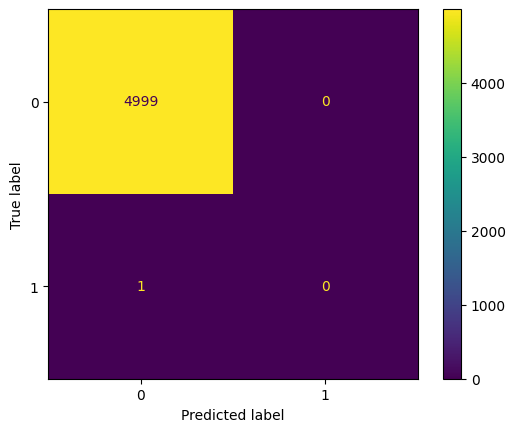

In [4]:
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test)
plt.show()

In [5]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(lr_model, '../project_files/models/logistic_regression.pkl')
print("Logistic Regression model saved!")

Logistic Regression model saved!


                   Feature  Coefficient
48          URG Flag Count     0.642348
0         Destination Port    -0.543944
46          PSH Flag Count     0.521090
66  Init_Win_bytes_forward     0.329922
51           Down/Up Ratio    -0.305073
38       Min Packet Length    -0.300999
7    Fwd Packet Length Min    -0.253340
68        act_data_pkt_fwd    -0.248987
2        Total Fwd Packets    -0.248684
62     Subflow Fwd Packets    -0.248684


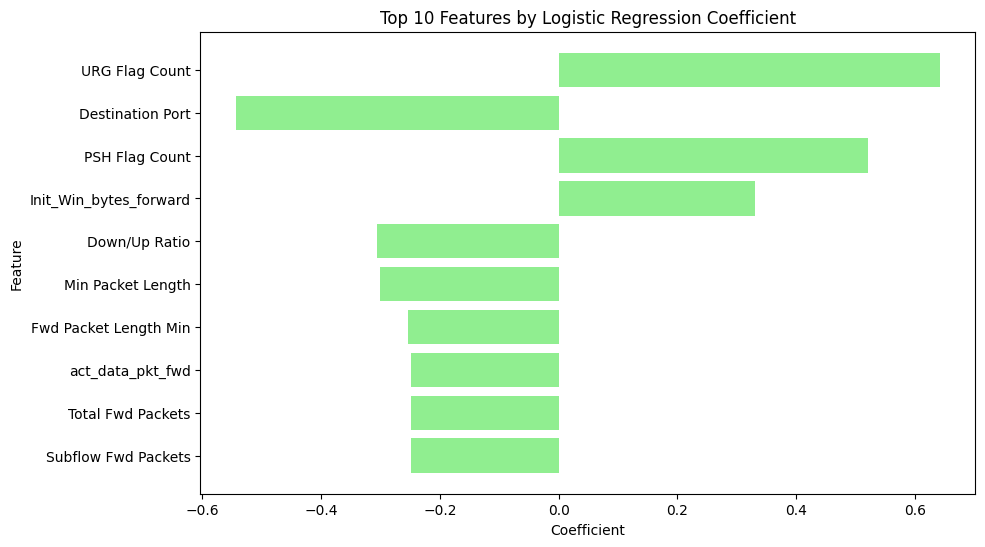

In [6]:
# Get coefficients
coefficients = lr_model.coef_[0]  # For binary classification
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Show top 10 features
top10 = feature_importance.head(10)
print(top10)

# Optional: Plot
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Coefficient'], color='lightgreen')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 10 Features by Logistic Regression Coefficient')
plt.gca().invert_yaxis()
plt.show()

In [8]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9998
